In [ ]:
import os
import json
import pandas as pd
from IPython.display import display

# Define the path to the experiments directory
experiments_dir = "experiments"

# --- FILTER OPTIONS ---
# Put the exact model_name you want to filter by (e.g., "stgcn_mamba", "bimamba").
# If you want to process ALL directories, leave this as None.
target_model_name = "stgcn_mamba"  # Set to None to process all directories

# --- NEW: MULTIPLE HYPERPARAMETERS DISPLAY OPTION ---
target_hyperparameters = ["loss_function", "window_size", "description"]

# --- NEW: STARTING PREFIX OPTION ---
# Only show experiments whose numeric suffix (e.g. the "42" in "stgcn_mamba-42")
# is >= this value, so you don't have to scroll through hundreds of experiments.
# Set to None to show everything from the start.
start_prefix = None  # e.g. 80

#region

# --- HIGHLIGHT SPECIFIC SUB-DIRECTORIES ---
highlight_subdirectories = [
    27, 31, 33, 37
]

highlight_subdirectories = [
    f"{target_model_name}-{int(item):02d}" if isinstance(item, int) or (isinstance(item, str) and item.isdigit()) else item
    for item in highlight_subdirectories
]

results = []

def extract_suffix_number(directory_name):
    try:
        suffix = directory_name.split('-', 1)[1]
        return int(''.join(filter(str.isdigit, suffix)) or 0)
    except Exception:
        return float('inf')

def to_number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

if os.path.exists(experiments_dir):
    entries = [entry for entry in os.listdir(experiments_dir) if os.path.isdir(os.path.join(experiments_dir, entry))]
    entries.sort(key=extract_suffix_number)

    for entry in entries:
        if target_model_name is not None:
            if not entry.startswith(f"{target_model_name}-"):
                continue 

        if start_prefix is not None and extract_suffix_number(entry) < start_prefix:
            continue
                
        sub_dir = os.path.join(experiments_dir, entry)
        metrics_file = os.path.join(sub_dir, "training_metrics.csv")
        hp_file = os.path.join(sub_dir, "hyperparameters.json")
        
        # Initialize defaults
        hp_values = {hp: "N/A" for hp in target_hyperparameters}
        best_epoch = "N/A"
        frame_f1 = "N/A"
        mean_iou = "N/A"
        segment_f1 = "N/A"
        average_score = "N/A"
        
        # 1. Grab Hyperparameters (Always happens)
        if os.path.exists(hp_file):
            try:
                with open(hp_file, 'r', encoding='utf-8') as f:
                    hp_data = json.load(f)
                    for hp in target_hyperparameters:
                        hp_values[hp] = hp_data.get(hp, "N/A")
            except json.JSONDecodeError:
                print(f"Warning: Could not parse {hp_file}")
        
        # 2. Grab Metrics (If they exist)
        if os.path.exists(metrics_file):
            try:
                df = pd.read_csv(metrics_file)
                required_cols = ['frame_f1', 'mean_iou', 'segment_f1']
                if all(col in df.columns for col in required_cols):
                    df['combined_score'] = df['frame_f1'] + df['mean_iou'] + df['segment_f1']
                    df['average_score'] = df['combined_score'] / 3
                    
                    best_idx = df['combined_score'].idxmax()
                    best_row = df.iloc[best_idx]
                    
                    best_epoch = int(best_row['epoch']) if 'epoch' in df.columns else best_idx + 1
                    frame_f1 = f"{best_row['frame_f1']:.3f}"
                    mean_iou = f"{best_row['mean_iou']:.3f}"
                    segment_f1 = f"{best_row['segment_f1']:.3f}"
                    average_score = f"{best_row['average_score']:.3f}"
                else:
                    # File exists but is empty or missing columns (e.g. training just started)
                    pass 
            except pd.errors.EmptyDataError:
                # File exists but has no data yet
                pass
            except Exception as e:
                print(f"Error processing metrics for '{entry}': {e}")
                
        # 3. Build the row (happens regardless of metrics existing)
        result_dict = {
            "Sub-directory": entry,
            "Best Epoch": best_epoch,
            "Frame F1": frame_f1,
            "Mean IoU": mean_iou,
            "Segment F1": segment_f1,
            "Average score": average_score
        }

        # Dynamically add EACH target hyperparameter
        for hp in target_hyperparameters:
            if hp == "overlap" and "window_size" in target_hyperparameters:
                result_dict[f"HP: {hp}"] = hp_values[hp]

                window_size_value = hp_values.get("window_size", "N/A")
                overlap_value = hp_values.get("overlap", "N/A")
                window_size_num = to_number(window_size_value)
                overlap_num = to_number(overlap_value)

                if window_size_num is not None and overlap_num is not None and window_size_num != 0:
                    result_dict["Overlap ratio"] = f"{round(overlap_num / window_size_num * 100, 1)}%"
                else:
                    result_dict["Overlap ratio"] = "N/A"
            else:
                result_dict[f"HP: {hp}"] = hp_values[hp]                            
        
        results.append(result_dict)

else:
    print(f"Directory '{experiments_dir}' not found. Please make sure it is in the same directory as this notebook.")

# Create a DataFrame
results_df = pd.DataFrame(results)

if not results_df.empty:
    
    highlighted_row_color = 'rgb(35, 46, 56)'
    
    def score_style(value, hue=120):
        if value == "N/A":
            return "color: gray;" # Grey out N/A text so it doesn't distract
            
        try:
            score = float(value)
        except (ValueError, TypeError):
            return ""

        lightness = 90 - score * 90
        lightness = max(10, min(60, lightness))
        return f"background-color: hsl({hue}, 30%, {lightness:.1f}%)"

    try:
        # Pandas >= 1.4.0
        styled_df = results_df.style.hide(axis="index")
        
        if highlight_subdirectories:
            highlight_set = set(highlight_subdirectories)
            def highlight_selected(row):
                return [
                    f"background-color: {highlighted_row_color}" if row["Sub-directory"] in highlight_set else ""
                    for _ in row
                ]
            styled_df = styled_df.apply(highlight_selected, axis=1)

        styled_df = styled_df.applymap(score_style, subset=['Average score'])
        styled_df = styled_df.applymap(lambda value: score_style(value, hue=0), subset=['Frame F1', 'Mean IoU', 'Segment F1'])
        display(styled_df)
    except AttributeError:
        # Pandas < 1.4.0
        styled_df = results_df.style.hide_index()

        if highlight_subdirectories:
            highlight_set = set(highlight_subdirectories)
            def highlight_selected(row):
                return [
                    f"background-color: {highlighted_row_color}" if row["Sub-directory"] in highlight_set else ""
                    for _ in row
                ]
            styled_df = styled_df.apply(highlight_selected, axis=1)

        styled_df = styled_df.applymap(score_style, subset=['Average score'])
        styled_df = styled_df.applymap(lambda value: score_style(value, hue=0), subset=['Frame F1', 'Mean IoU', 'Segment F1'])
        display(styled_df)
else:
    print("No results found. Either the directory is empty, or no folders matched your criteria.")
#endregion

In [ ]:
experiments_dir = "experiments"

target_model_name = "stgcn_mamba"  # Set to None to process all directories

start_prefix = 277  # e.g. 80

#region

import os
import json
import pandas as pd
from IPython.display import display

# --- HIGHLIGHT SPECIFIC SUB-DIRECTORIES ---
highlight_subdirectories = [
    27, 31, 33, 37
]

highlight_subdirectories = [
    f"{target_model_name}-{int(item):02d}" if isinstance(item, int) or (isinstance(item, str) and item.isdigit()) else item
    for item in highlight_subdirectories
]

results = []

def extract_suffix_number(directory_name):
    try:
        suffix = directory_name.split('-', 1)[1]
        return int(''.join(filter(str.isdigit, suffix)) or 0)
    except Exception:
        return float('inf')

def to_number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

if os.path.exists(experiments_dir):
    entries = [entry for entry in os.listdir(experiments_dir) if os.path.isdir(os.path.join(experiments_dir, entry))]
    entries.sort(key=extract_suffix_number)

    for entry in entries:
        if target_model_name is not None:
            if not entry.startswith(f"{target_model_name}-"):
                continue

        if start_prefix is not None and extract_suffix_number(entry) < start_prefix:
            continue

        sub_dir = os.path.join(experiments_dir, entry)
        hw_file = os.path.join(sub_dir, "hardware_summary.json")
        hp_file = os.path.join(sub_dir, "hyperparameters.json")

        # Initialize defaults
        experiment_name = entry
        description = "N/A"
        total_hours = "N/A"
        avg_epoch_time = "N/A"
        max_gpu_mem = "N/A"
        gpu_util = "N/A"
        total_restarts = "N/A"
        nan_loss_count = "N/A"

        # 1. Grab hyperparameters (experiment name + description)
        if os.path.exists(hp_file):
            try:
                with open(hp_file, 'r', encoding='utf-8') as f:
                    hp_data = json.load(f)
                    basename = hp_data.get("basename")
                    prefix = hp_data.get("prefix")
                    if basename is not None and prefix is not None:
                        experiment_name = f"{basename}-{prefix}"
                    description = hp_data.get("description", "N/A")
            except json.JSONDecodeError:
                print(f"Warning: Could not parse {hp_file}")

        # 2. Grab hardware summary
        if os.path.exists(hw_file):
            try:
                with open(hw_file, 'r', encoding='utf-8') as f:
                    hw_data = json.load(f)

                total_seconds = to_number(hw_data.get("total_training_seconds"))
                total_hours = f"{total_seconds / 3600:.2f}h" if total_seconds is not None else "N/A"

                avg_epoch_time = hw_data.get("average_time_per_epoch", "N/A")

                max_mem = to_number(hw_data.get("max_gpu_memory_used_gb"))
                max_gpu_mem = f"{max_mem:.3f} GB" if max_mem is not None else "N/A"

                util = to_number(hw_data.get("average_gpu_utilization_percent"))
                gpu_util = f"{util:.1f}%" if util is not None else "N/A"

                total_restarts = hw_data.get("total_training_restarts", "N/A")
                nan_loss_count = hw_data.get("total_nan_loss_count_latest_run", "N/A")
            except json.JSONDecodeError:
                print(f"Warning: Could not parse {hw_file}")

        # 3. Build the row (happens regardless of hardware summary existing)
        results.append({
            "Sub-directory": entry,
            "Description": description,
            "Total Time (h)": total_hours,
            "Avg Time / Epoch": avg_epoch_time,
            "Max GPU Mem": max_gpu_mem,
            "GPU Util %": gpu_util,
            "Restarts": total_restarts,
            "NaN Loss Count": nan_loss_count,
        })

else:
    print(f"Directory '{experiments_dir}' not found. Please make sure it is in the same directory as this notebook.")

# Create a DataFrame
hardware_df = pd.DataFrame(results)

if not hardware_df.empty:

    highlighted_row_color = 'rgb(35, 46, 56)'

    def util_style(value):
        try:
            pct = float(str(value).rstrip('%'))
        except (ValueError, TypeError):
            return "color: gray;"
        lightness = 90 - (pct / 100) * 80
        lightness = max(10, min(80, lightness))
        return f"background-color: hsl(120, 30%, {lightness:.1f}%)"

    def warning_style(value):
        try:
            count = float(value)
        except (ValueError, TypeError):
            return "color: gray;"
        if count <= 0:
            return ""
        lightness = max(20, 70 - count * 8)
        return f"background-color: hsl(0, 60%, {lightness:.1f}%)"

    try:
        styled_hw_df = hardware_df.style.hide(axis="index")
    except AttributeError:
        styled_hw_df = hardware_df.style.hide_index()

    if highlight_subdirectories:
        highlight_set = set(highlight_subdirectories)
        def highlight_selected(row):
            return [
                f"background-color: {highlighted_row_color}" if row["Sub-directory"] in highlight_set else ""
                for _ in row
            ]
        styled_hw_df = styled_hw_df.apply(highlight_selected, axis=1)

    styled_hw_df = styled_hw_df.applymap(util_style, subset=['GPU Util %'])
    styled_hw_df = styled_hw_df.applymap(warning_style, subset=['Restarts', 'NaN Loss Count'])
    display(styled_hw_df)
else:
    print("No results found. Either the directory is empty, or no folders matched your criteria.")
#endregion


/var/folders/6v/zjm68lx93s91k1tz4brksldw0000gn/T/ipykernel_99670/4005954050.py:163: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_hw_df = styled_hw_df.applymap(util_style, subset=['GPU Util %'])
/var/folders/6v/zjm68lx93s91k1tz4brksldw0000gn/T/ipykernel_99670/4005954050.py:164: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_hw_df = styled_hw_df.applymap(warning_style, subset=['Restarts', 'NaN Loss Count'])


Sub-directory,Description,Total Time (h),Avg Time / Epoch,Max GPU Mem,GPU Util %,Restarts,NaN Loss Count
stgcn_mamba-277,"--NEW DATASPLIT-- overlap ratio (0/16), loss=weighted_ce, spatial_angles",3.80h,7m 52s,0.177 GB,63.0%,0,5
stgcn_mamba-278,"--NEW DATASPLIT-- overlap ratio (0/32), loss=weighted_ce, spatial_angles",2.45h,4m 45s,0.289 GB,75.7%,0,10
stgcn_mamba-279,"--NEW DATASPLIT-- overlap ratio (0/64), loss=weighted_ce, spatial_angles",1.49h,3m 12s,0.500 GB,89.1%,0,7
stgcn_mamba-280,"--NEW DATASPLIT-- overlap ratio (0/128), loss=weighted_ce, spatial_angles",1.45h,3m 0s,0.508 GB,94.2%,0,0
stgcn_mamba-281,"--NEW DATASPLIT-- overlap ratio (0/256), loss=weighted_ce, spatial_angles",1.44h,2m 53s,0.956 GB,96.2%,0,0
stgcn_mamba-282,"--NEW DATASPLIT-- overlap ratio (0/16), loss=weighted_ce, spatial_angles",2.56h,5m 55s,0.222 GB,80.2%,0,4
stgcn_mamba-283,"--NEW DATASPLIT-- overlap ratio (0/32), loss=weighted_ce, spatial_angles",1.73h,3m 51s,0.335 GB,89.6%,0,3
stgcn_mamba-284,"--NEW DATASPLIT-- overlap ratio (0/64), loss=weighted_ce, spatial_angles",1.32h,2m 56s,0.545 GB,92.8%,0,2
stgcn_mamba-285,"--NEW DATASPLIT-- overlap ratio (0/128), loss=weighted_ce, spatial_angles",1.08h,2m 49s,0.555 GB,95.5%,0,0
stgcn_mamba-286,"--NEW DATASPLIT-- overlap ratio (0/256), loss=weighted_ce, spatial_angles",1.50h,2m 44s,1.001 GB,96.8%,0,0


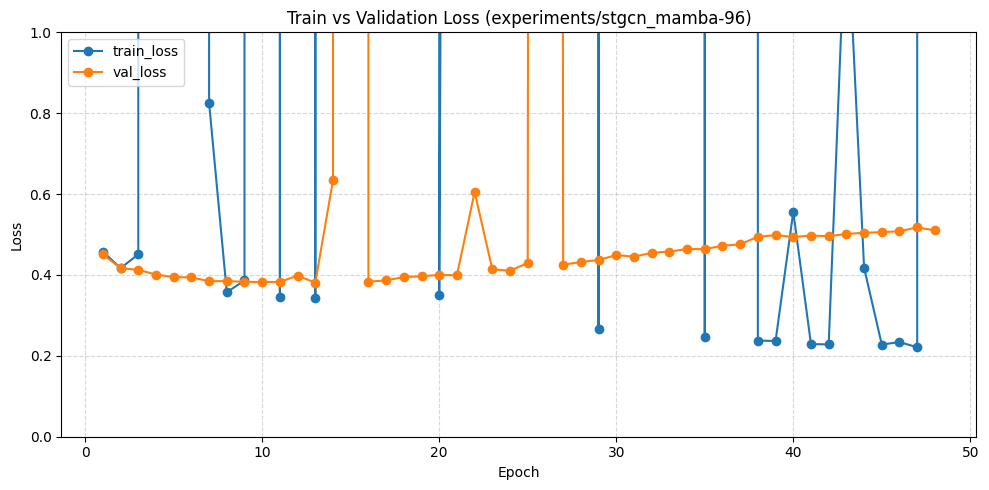

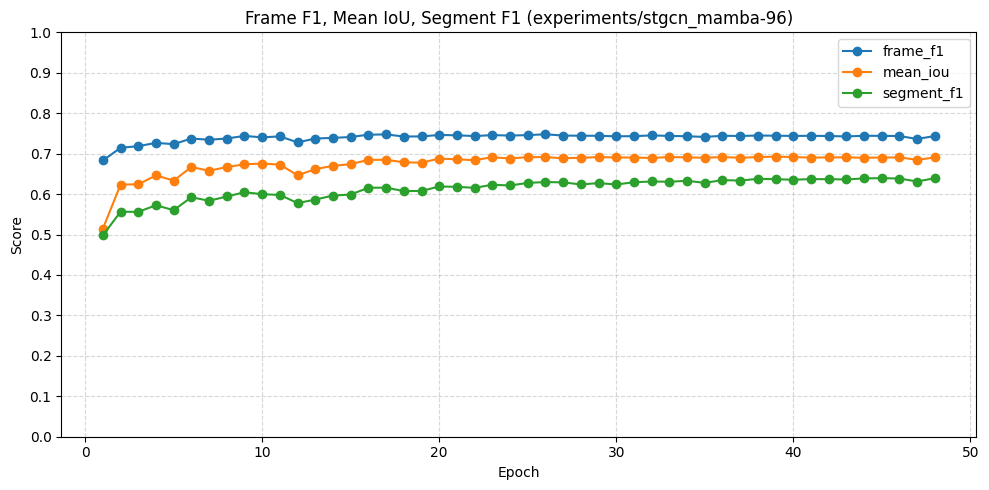

In [7]:
# Select the specific experiment sub-directory to plot
selected_subdir = os.path.join("experiments", "stgcn_mamba-96")

#region
metrics_file = os.path.join(selected_subdir, "training_metrics.csv")

import matplotlib.pyplot as plt
import numpy as np

# Load the metrics CSV and ignore rows where epoch is not an integer
raw_df = pd.read_csv(metrics_file, dtype=str)
raw_df['epoch'] = pd.to_numeric(raw_df['epoch'], errors='coerce')
df = raw_df[raw_df['epoch'].notna()].copy()
df['epoch'] = df['epoch'].astype(int)

# Convert the relevant columns to numeric for plotting
for col in ['train_loss', 'val_loss', 'frame_f1', 'mean_iou', 'segment_f1']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort by epoch just in case
df = df.sort_values('epoch')

# Plot 1: train_loss and val_loss
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['train_loss'], marker='o', label='train_loss')
plt.plot(df['epoch'], df['val_loss'], marker='o', label='val_loss')
plt.title(f"Train vs Validation Loss ({selected_subdir})")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: frame_f1, mean_iou, segment_f1
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['frame_f1'], marker='o', label='frame_f1')
plt.plot(df['epoch'], df['mean_iou'], marker='o', label='mean_iou')
plt.plot(df['epoch'], df['segment_f1'], marker='o', label='segment_f1')
plt.title(f"Frame F1, Mean IoU, Segment F1 ({selected_subdir})")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
#endregion